# Chuẩn bị

**Cài đặt các Thư viện sử dụng**

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt dataFrame**

In [6]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**

In [7]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

# Khám phá dữ liệu

**Xem thông tin dữ liệu**

In [8]:
data_df.head(5)

,title,text,label
0,Cấm biển di dân khỏi vùng nguy hiểm từ Quảng N...,Các tỉnh ven biển phía Bắc cấp tập di dân tạm ...,0
1,Hội Cựu Công an nhân dân là thành viên Mặt trậ...,Ủy ban Trung ương Mặt trận Tổ quốc (MTTQ) Việt...,0
2,Thêm 30 cá thể hổ và sư tử ở Vườn thú Mỹ Quỳnh...,Ngày 2-10 bà Đinh Thị Phương Khanh Phó Giám đố...,0
3,Đà Lạt: Lũ cuốn trôi ô tô 1 người mất tích,Khoảng 13 giờ 30 phút ngày 2-10 tại đập tràn t...,0
4,Kiên Giang: Cất bốc 19 hài cốt liệt sĩ tại huy...,Ngày 2-10 thông tin từ Bộ Chỉ huy quân sự tỉnh...,0


**Xáo trộn dữ liệu**

In [9]:
data_df=data_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [10]:
data_df.head(5)

,title,text,label
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1
1,Biển Đông: Trung Quốc âm mưu chia rẽ Việt Nam ...,Nguồn hình ảnh BBC/Virma Simonette Philippines...,1
2,Mất căn cước công dân ở nước ngoài tôi có được...,Tôi đã từng làm căn cước công dân (CCCD). Cách...,0
3,Đường dây dùng trẻ em phục vụ khiêu dâm bị phá...,Đồng NaiCác nghi phạm mua bán sử dụng người dư...,0
4,Phạm Minh Hoàng: Hội Thánh Truyền Giáo Phục Hư...,Tình hình dịch Covid-19 tại Việt Nam đang rất ...,1


**Mô tả của dữ liệu**

In [11]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


In [12]:
data_df.describe().round(1)

,label
count,12600.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,1.0


**Kích thước của DataFrame và danh sách các tên cột**

In [13]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

(12600, 3)
['title', 'text', 'label']


**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [14]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
3


**Kiểm tra dữ liệu có bị lặp**

In [15]:
dup=data_df.index.duplicated().sum()
dup

0

**Kiểm tra dữ liệu có bị thiếu**

In [16]:
data_df['title'].isnull().sum()

0

In [17]:
data_df['text'].isnull().sum()

0

In [18]:
data_df['label'].isnull().sum()

0

**Kiểm tra loại dữ liệu**

In [19]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [20]:
open_object_dtype(data_df['title'])

{str}

In [21]:
open_object_dtype(data_df['text'])

{str}

In [22]:
open_object_dtype(data_df['label'])

{int}

**Kiểm tra số từ của title và text**

In [23]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [24]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,12600.000000,12600.000000
mean,13.281905,913.570556
std,4.446797,828.093960
min,1.000000,52.000000
25%,10.000000,384.000000
50%,14.000000,699.000000
75%,16.000000,1174.000000
max,47.000000,15495.000000


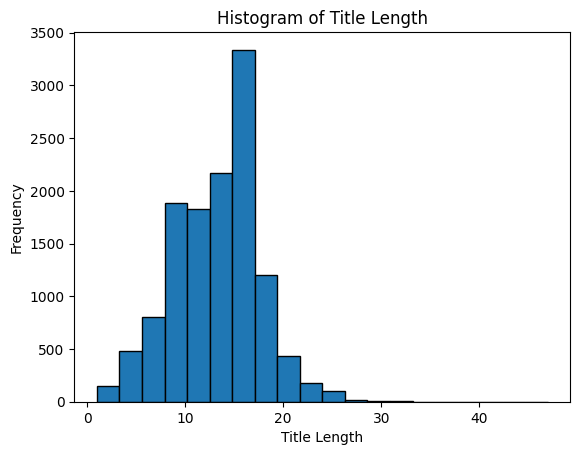

In [25]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

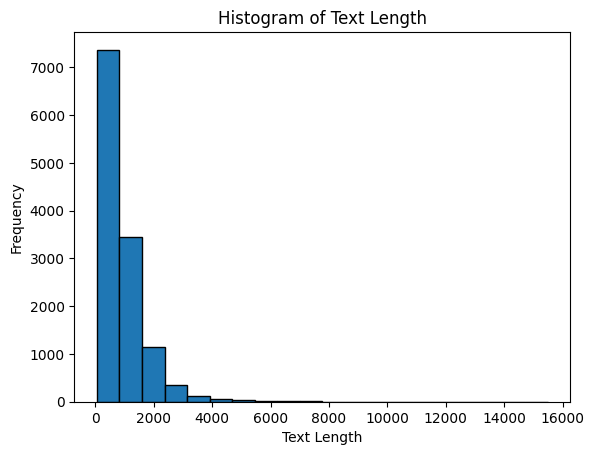

In [26]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

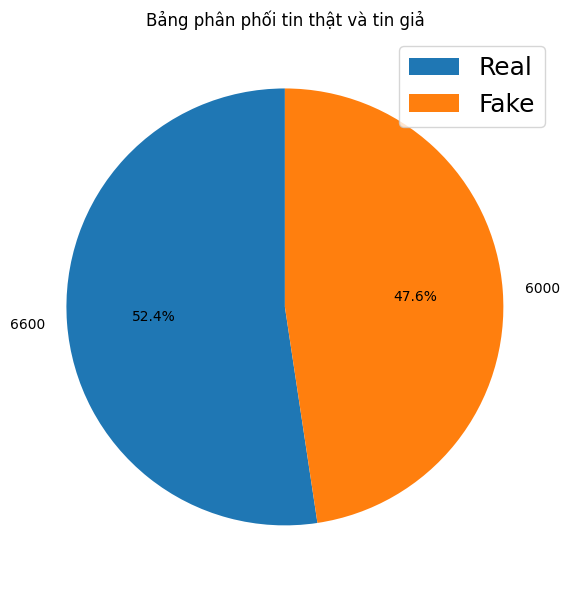

In [27]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [28]:
len_title_sum=0

for i in data_df['title']:
    len_word=i.split()
    len_title_sum += len(len_word)

avg_title=len_title_sum/data_df['title'].count()

avg_title

13.282619047619047

**Độ dài lớn nhất của tiêu đề**

In [29]:
max_title_len=0
for i in data_df['title']:
    len_word = i.split()
    if len(len_word) > max_title_len:
        max_title_len = len(len_word)
max_title_len

47

**Độ dài nhỏ nhất của tiêu đề**

In [30]:
min_title_len=max_title_len
for i in data_df['title']:
    len_word=i.split()
    if len(len_word) < min_title_len:
        min_title_len = len(len_word)

min_title_len

1

**Chiều dài trung bình text của 1 tin tức**

In [31]:
len_text_sum=0

for i in data_df['text']:
    len_word=i.split()
    len_text_sum += len(len_word)

avg_text=len_text_sum/data_df['text'].count()

avg_text

913.5705555555555

**Độ dài lớn nhất của text**

In [32]:
max_text_len=0

for i in data_df['text']:
    len_word=i.split()
    if len(len_word)>max_text_len:
        max_text_len=len(len_word)

max_text_len

15495

**Độ dài nhỏ nhất của text**

In [33]:
min_text_len = max_text_len

for i in data_df['text']:
    len_word=i.split()
    if len(len_word) < min_text_len:
        min_text_len = len(len_word)

min_text_len

52

**Tổng số từ trong title**

In [34]:
total_words = data_df['title'].str.split().map(len).sum()
total_words

167361

**Tổng số từ trong text**

In [35]:
total_words = data_df['text'].str.split().map(len).sum()
total_words

11510989

**Số từ khác biệt trong title**

In [36]:
unique_words = len(set(' '.join(data_df['title']).split()))
unique_words

11752

**Số từ khác biệt trong text**

In [37]:
unique_words = len(set(' '.join(data_df['text']).split()))
unique_words

115253

**Số từ khác biệt trong title và text**

In [38]:
combined_text = ' '.join(data_df['title']) + ' ' + ' '.join(data_df['text'])
unique_words_combined = len(set(combined_text.split()))
unique_words_combined

117203

# Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

**Thư viện để xử lý**

In [39]:
from pyvi import ViTokenizer

In [40]:
def wordopt(text):
    text = text.lower()
    text = re.sub('[%s]' % re.escape("""!’‘–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…؛"""), ' ', text)
    text = re.sub('https?://\S+|www\.\S+|https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('<.*?>+', ' ', text)
    # text = re.sub('\[.*?\]', ' ', text)
    text = re.sub('\\W', ' ', text)
    # text = re.sub('\w*\d\w*', ' ', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.strip()

    # update_text = ""
    # for word in text.split():
    #     if word not in stopwords:
    #         update_text += word + " "
        
    return text

In [41]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)

**Hợp nhất title và text**

In [42]:
data_df['article'] = data_df["title"] +' '+  data_df["text"] 

In [43]:
data_df.head(1)

,title,text,label,title_length,text_length,article
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1,5,954,Lưỡi gỗ Nguyễn Viết Thông Hội đồng lý luận tru...


**Áp dụng các xử lý dữ liệu**

In [44]:
data_df['Compound_Content'] = data_df['article'].apply(wordopt)

In [45]:
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(tokenizerVN)

In [46]:
data_df.head(1)

,title,text,label,title_length,text_length,article,Compound_Content,Compound_Content_SW
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1,5,954,Lưỡi gỗ Nguyễn Viết Thông Hội đồng lý luận tru...,lưỡi gỗ nguyễn viết thông hội đồng lý luận tru...,lưỡi gỗ nguyễn viết thông hội_đồng lý_luận tru...


**Tổng số từ**

In [47]:
total_words = data_df['Compound_Content_SW'].str.split().map(len).sum()
total_words

8814661

**Số từ khác biệt còn lại**

In [48]:
unique_words_combined = len(set(' '.join(data_df['Compound_Content_SW']).split()))
unique_words_combined

67029

In [49]:
data_df.sample(10)

,title,text,label,title_length,text_length,article,Compound_Content,Compound_Content_SW
2520,Mất Mùa Là Tại Thiên Tai!,Ở Việt Nam không ai là không biết đến 2 câu vè...,1,6,1640,Mất Mùa Là Tại Thiên Tai! Ở Việt Nam không ai ...,mất mùa là tại thiên tai ở việt nam không ai l...,mất_mùa là tại thiên_tai ở việt nam không ai l...
8102,Nhà cho công nhân quá ít!,Đó là lời than thở của ông Nguyễn Xuân Phúc sa...,1,6,852,Nhà cho công nhân quá ít! Đó là lời than thở c...,nhà cho công nhân quá ít đó là lời than thở củ...,nhà cho công_nhân quá ít đó là lời than_thở củ...
9832,Khi kẻ khủng bố gắp lửa bỏ tay người,Người dân Miền Nam sống dưới chế độ Cộng Hoà k...,1,9,1961,Khi kẻ khủng bố gắp lửa bỏ tay người Người dân...,khi kẻ khủng bố gắp lửa bỏ tay người người dân...,khi kẻ khủng_bố gắp lửa bỏ tay người_người dân...
11308,Phó Chủ tịch Quốc hội Nguyễn Thị Thanh thăm và...,Ngay sau đó Phó Chủ tịch Quốc hội đã có cuộc g...,0,14,438,Phó Chủ tịch Quốc hội Nguyễn Thị Thanh thăm và...,phó chủ tịch quốc hội nguyễn thị thanh thăm và...,phó_chủ_tịch quốc_hội nguyễn thị thanh thăm và...
7904,Ga tàu thủy Bạch Đằng và sự áp đặt ngôn từ,Nguồn hình ảnh Nguyễn Kim Toản Dòng chữ Ga tàu...,1,11,1421,Ga tàu thủy Bạch Đằng và sự áp đặt ngôn từ Ngu...,ga tàu thủy bạch đằng và sự áp đặt ngôn từ ngu...,ga tàu thủy_bạch đằng và sự áp_đặt ngôn_từ ngu...
9311,Sạt lở tạo hố sâu trên đường ở Lâm Đồng,. Sau những trận mưa lớn kéo dài sáng nay (ngà...,0,10,178,Sạt lở tạo hố sâu trên đường ở Lâm Đồng . Sau ...,sạt lở tạo hố sâu trên đường ở lâm đồng sau nh...,sạt_lở tạo hố sâu trên đường ở lâm đồng sau nh...
4490,THƯ KÊU CỨU GỬI BỘ TRƯỞNG CÔNG AN TRẦN ĐẠI QUA...,Chúng tôi là (1) Lê Anh Hùng sinh ngày 27/8/19...,1,16,177,THƯ KÊU CỨU GỬI BỘ TRƯỞNG CÔNG AN TRẦN ĐẠI QUA...,thư kêu cứu gửi bộ trưởng công an trần đại qua...,thư kêu cứu gửi bộ_trưởng công_an trần đại qua...
5695,Nam thanh niên quan hệ tình dục với 76 phụ nữ ...,Ngày 28/6 Tòa án sơ thẩm Singapore tuyên phạt ...,0,16,539,Nam thanh niên quan hệ tình dục với 76 phụ nữ ...,nam thanh niên quan hệ tình dục với phụ nữ v...,nam thanh_niên quan_hệ tình_dục với phụ_nữ và ...
6153,Cảnh sát 141 chặn bắt 45 quái xế trong đêm Tru...,Ngày 18/9 Công an TP Hà Nội cho biết trong đêm...,0,12,287,Cảnh sát 141 chặn bắt 45 quái xế trong đêm Tru...,cảnh sát chặn bắt quái xế trong đêm trung ...,cảnh_sát chặn bắt quái xế trong đêm trung_thu ...
7293,13 người chết và mất tích do sạt lở lũ cuốn sa...,Đại diện Cục Quản lý đê điều và Phòng chống th...,0,14,253,13 người chết và mất tích do sạt lở lũ cuốn sa...,người chết và mất tích do sạt lở lũ cuốn sau b...,người chết và mất_tích do sạt_lở lũ cuốn sau b...


**Xác định tần suất xuất hiện các từ trong từng tài liệu**

In [50]:
from collections import Counter

In [51]:
word_counts_per_document = []

# Duyệt qua từng tài liệu
for doc in data_df['Compound_Content_SW']:
    words_in_doc = set(doc.split())  # Sử dụng set để loại bỏ từ trùng trong mỗi tài liệu
    word_counts_per_document.append(words_in_doc)

# Bước 4: Đếm tổng số lần xuất hiện của các từ trong tất cả các tài liệu (mỗi từ chỉ tính một lần trong một tài liệu)
total_word_counts = Counter()

# Duyệt qua danh sách các từ trong từng tài liệu và cập nhật tổng số đếm
for word_set in word_counts_per_document:
    total_word_counts.update(word_set)

In [52]:
import csv
save_Count_file = os.path.join("", "Count_Word.csv")
with open(save_Count_file, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(["Word",'number', "Frequency"])  # Header
    
    for word, count in total_word_counts.most_common():
        writer.writerow([word, count,count / len(data_df)])

# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [53]:
def tokenize(sentence):
    return tokenizerVN(sentence).split()

**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [54]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [55]:
# model_vector_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_vectorizer_CV.joblib")
# model_RFC_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_RFC_model_CV.joblib")

In [56]:
model_vector_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_vectorizer_TF.joblib")
# model_RFC_TF = os.path.join("../../Vector/Vietnamese/TF", "Vietnamese_RFC_model_TF.joblib")

In [57]:
# model_vector_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_vectorizer_W2V.joblib")
# model_RFC_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_RFC_model_W2V.joblib")

In [58]:
# model_vector_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_vectorizer_D2V.joblib")
# model_RFC_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_RFC_model_D2V.joblib")

## Các mô hình vector 

**CountVectorizer**

In [59]:
vectorizerCV = CountVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=4,          
                            max_df=0.3,            
                            max_features=26305,              
                            ngram_range=(1, 3)        
                            )

In [60]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

**TfidfVectorizer**

In [61]:
vectorizerTF = TfidfVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=4,          
                            max_df=0.3,            
                            max_features=26305, 
                            use_idf=True, 
                            ngram_range=(1,3)
                            )

In [62]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

**Word2Vec**

In [63]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [64]:
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=150,  # Kích thước vector, có thể điều chỉnh để xem ảnh hưởng
    window=5,         # Kích thước cửa sổ ngữ cảnh
    min_count=4,      # Số lần tối thiểu từ phải xuất hiện để được giữ lại
    workers=4,        # Số lượng luồng để huấn luyện
    sg=1,             # Sử dụng Skip-gram (0 cho CBOW, 1 cho Skip-gram)
    epochs=20,        # Số lần lặp để huấn luyện
    negative=5,       # Số lượng negative samples cho mỗi positive sample
    alpha=0.025,      # Tỷ lệ học ban đầu
    min_alpha=0.00025,  # Tỷ lệ học nhỏ nhất
    seed=42           # Hạt giống để đảm bảo tính tái lặp
)

In [65]:
# Function to calculate the average Word2Vec vector for each sentence
def sentence_vector(sentence, model):
    # Get vectors for words in the sentence if they exist in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        # Calculate the mean of the word vectors for the sentence
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words in the sentence are in the vocabulary
        return np.zeros(model.vector_size)

In [66]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

**Doc2Vec**

In [67]:
def preprocess(doc):
    tokens = tokenize(doc)
    return [word for word in tokens if word not in stopwords]

**Chuẩn bị dữ liệu**

In [68]:
X_train_preprocessed = [preprocess(doc) for doc in X_train]
X_test_preprocessed = [preprocess(doc) for doc in X_test]

In [69]:
documents = [TaggedDocument(preprocess(doc), [i]) for i, doc in enumerate(X_train)]

In [70]:
# Khởi tạo và huấn luyện mô hình Doc2Vec
vectorizerD2V = Doc2Vec(vector_size=150, window=5, 
                        min_count=4, workers=4, dm=1, 
                        negative=5, alpha=0.025, 
                        min_alpha=0.00025, seed=42)
vectorizerD2V.build_vocab(documents)
vectorizerD2V.train(documents, total_examples=vectorizerD2V.corpus_count, epochs=20)

In [71]:
print(f"Number of documents in the corpus: {vectorizerD2V.corpus_count}")

Number of documents in the corpus: 9450


In [72]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc) for doc in X_train_preprocessed]
Xv_testD2V = [vectorizerD2V.infer_vector(doc) for doc in X_test_preprocessed]

# Bước 1: Thuật toán RFC

## Áp dụng các cách vector với RFC

In [73]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

**CountVectorizer**

In [74]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

**tfidfVectorizer**

In [75]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

**Word2Vec**

In [76]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

**Doc2Vec**

In [77]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

## Đánh giá mô hình

**Vẽ hình**

In [78]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

In [79]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

**Tính toán đánh giá**

In [80]:
def evaluate_model(y_true, y_pred, name_model, save=False):
    
    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }

    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation_metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/VietNamese", f"Vietnamese_Evaluate_{name_model}.csv")
        metrics_df.to_csv(path_evaluate, index=False)

## Kết quả các model

### CountVectorizer

0.9736507936507937
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



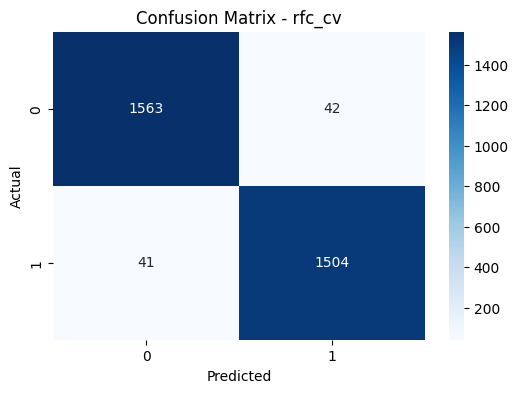

In [81]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv", save=True)

### TfidfVectorizer 

0.9733333333333334
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



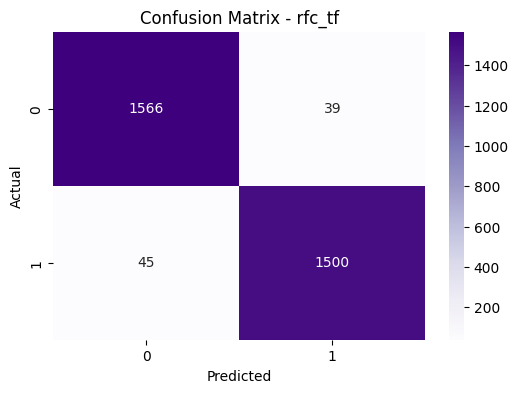

In [82]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf", save=True)

### Word2Vec

0.9657142857142857
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1605
           1       0.97      0.96      0.96      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



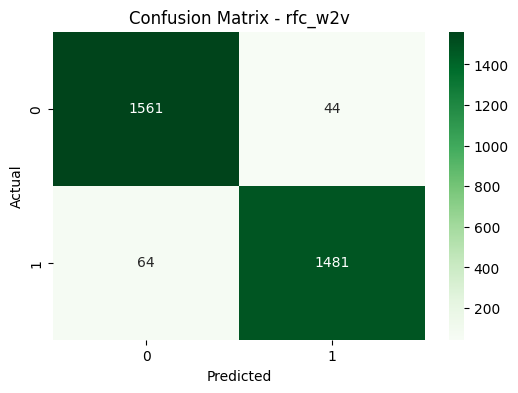

In [83]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v", save=True)


## Doc2Vec

0.9412698412698413
-------------------

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1605
           1       0.93      0.96      0.94      1545

    accuracy                           0.94      3150
   macro avg       0.94      0.94      0.94      3150
weighted avg       0.94      0.94      0.94      3150

-------------------



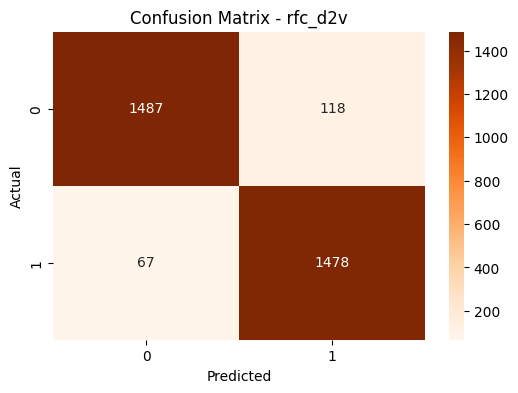

In [84]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v", save=True)

*Save model Vector*

In [85]:
# joblib.dump(vectorizerCV, model_vector_CV)
joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

['../../Vector/Vietnamese\\Vietnamese_vectorizer_TF.joblib']

# Bước 2:Vector hóa TF-IDF

## Navie bayes

In [86]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)

0.9546031746031746
-------------------

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1605
           1       0.95      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



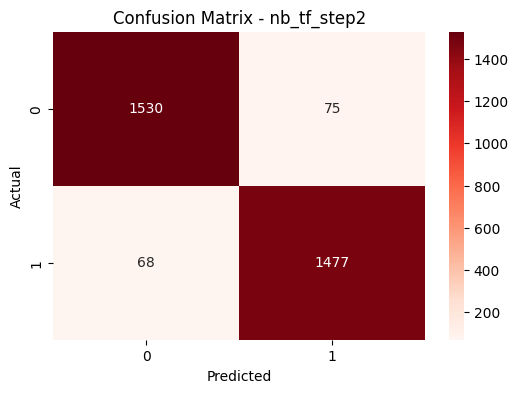

In [87]:
accuracy = accuracy_score(y_test, y_pred_nb) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_nb))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_nb,name_model="nb_tf_step2",save=True)

## DecisionTree

In [88]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)

0.9149206349206349
-------------------

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1605
           1       0.91      0.92      0.91      1545

    accuracy                           0.91      3150
   macro avg       0.91      0.92      0.91      3150
weighted avg       0.92      0.91      0.91      3150

-------------------



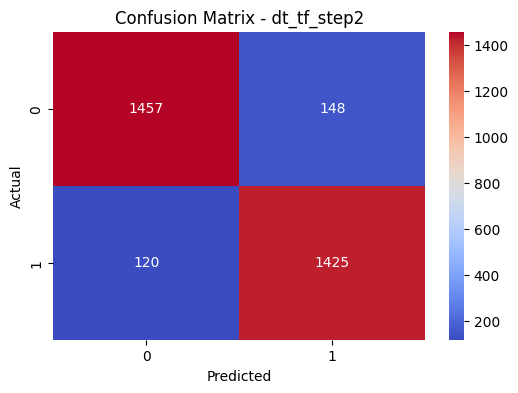

In [89]:
accuracy = accuracy_score(y_test, y_pred_dt) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_dt))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_dt,name_model="dt_tf_step2",save=True)

## RandomForest

In [90]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)

0.9733333333333334
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



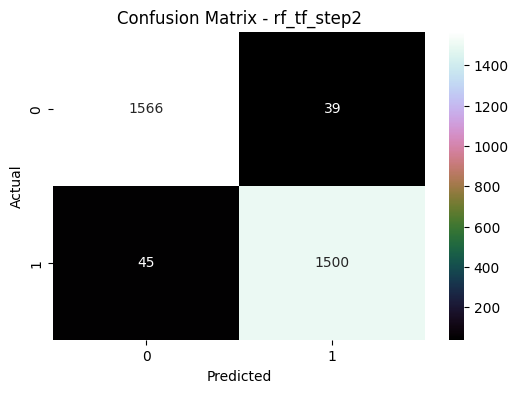

In [91]:
accuracy = accuracy_score(y_test, y_pred_rf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_rf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_rf,name_model="rf_tf_step2",save=True)

## SVM

In [92]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)

0.9834920634920635
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1605
           1       0.99      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



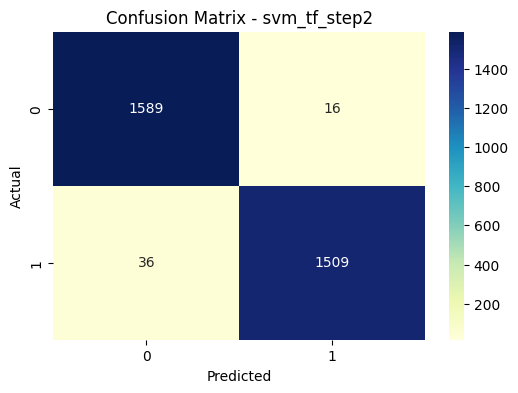

In [93]:
accuracy = accuracy_score(y_test, y_pred_svm) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_svm))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_svm,name_model="svm_tf_step2",save=True)

## LogisticRegression

In [94]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(Xv_trainTF, y_train)
y_pred_lr = lr_model.predict(Xv_testTF)

0.9758730158730159
-------------------

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1605
           1       0.98      0.97      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



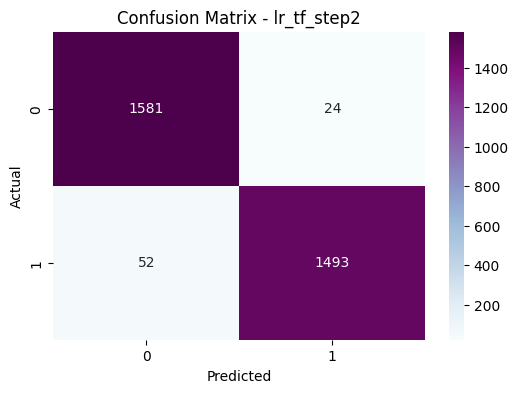

In [95]:
accuracy = accuracy_score(y_test, y_pred_lr) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_lr))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_lr,name_model="lr_tf_step2",save=True)

## GradientBoostingClassifier

In [96]:
gbc_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_model.fit(Xv_trainTF, y_train)
y_pred_gbc = gbc_model.predict(Xv_testTF)

0.9603174603174603
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1605
           1       0.97      0.95      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



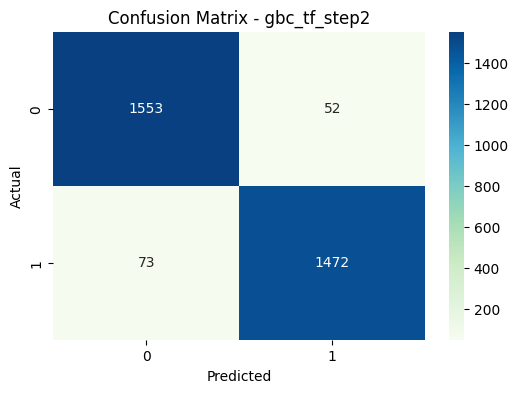

In [97]:
accuracy = accuracy_score(y_test, y_pred_gbc) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_gbc,name_model="gbc_tf_step2",save=True)

**save**

In [98]:
model_SVM_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_SVM_model_TF.joblib")
joblib.dump(svm_model, model_SVM_TF)

['../../Vector/Vietnamese\\Vietnamese_SVM_model_TF.joblib']

In [99]:
model_GBC_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_RFC_model_TF.joblib")
joblib.dump(gbc_model, model_GBC_TF)

['../../Vector/Vietnamese\\Vietnamese_RFC_model_TF.joblib']